Animation size has reached 20990977 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


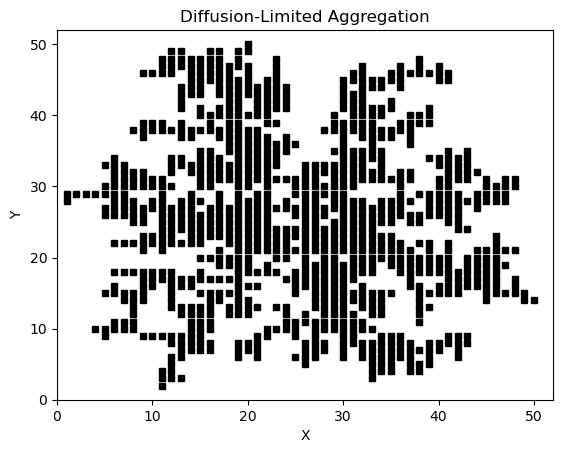

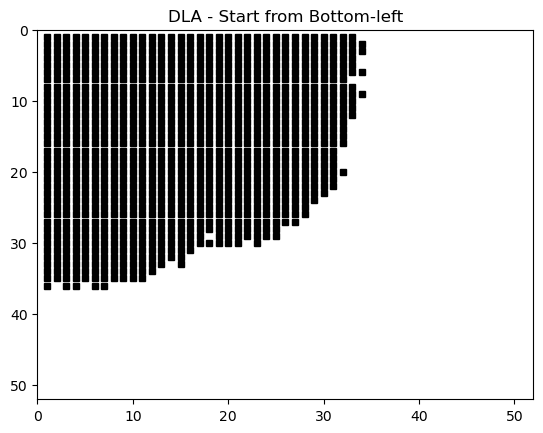

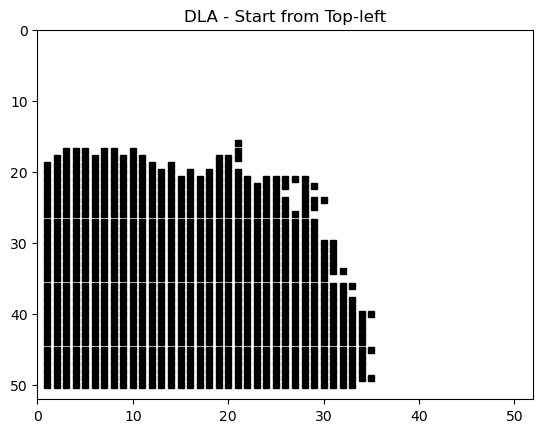

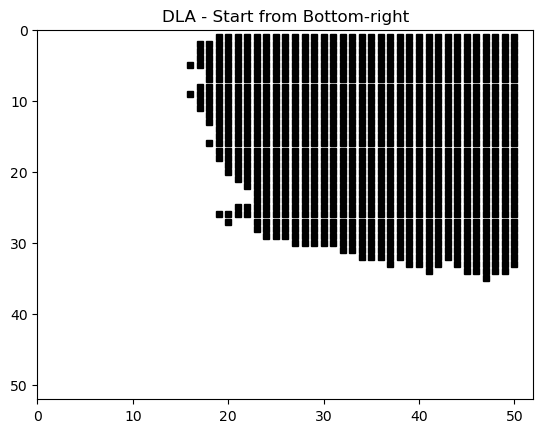

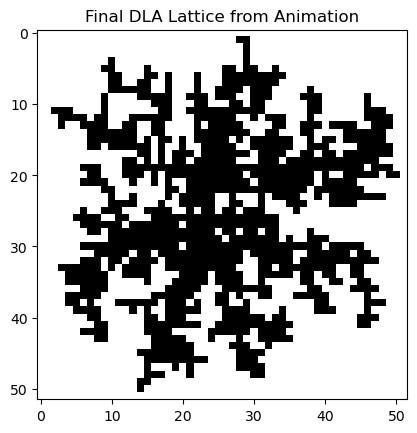

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

h, w = 50, 50
lattice = np.zeros((h + 2, w + 2))  

x0 = w // 2 + 1  
y0 = h // 2 + 1  
lattice[x0, y0] = 1

fig, ax = plt.subplots()
xi, yi = np.where(lattice)
hl, = ax.plot(xi, yi, linestyle="none", markersize=5, marker="s", color='black')
ax.set_xlim(0, w + 2)
ax.set_ylim(0, h + 2)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Diffusion-Limited Aggregation')

def update(frame):
    global lattice, xi, yi
    
    intro_points = [
        (1, 1),  
        (1, h), 
        (w, 1)   
    ]
    x, y = intro_points[frame % len(intro_points)] if frame < len(intro_points) else \
           (np.random.randint(1, w + 1), np.random.randint(1, h + 1))

    max_iterations = 10000  
    for _ in range(max_iterations):
        direction = np.random.randint(0, 8)
        dx, dy = {
            0: (1, 0), 1: (-1, 0), 2: (0, 1), 3: (0, -1),
            4: (1, 1), 5: (-1, -1), 6: (1, -1), 7: (-1, 1)
        }[direction]

        x_new = x + dx
        y_new = y + dy

        x_new = max(1, min(x_new, w))
        y_new = max(1, min(y_new, h))

        neighbors = [
            lattice[x_new - 1, y_new], lattice[x_new + 1, y_new],
            lattice[x_new, y_new - 1], lattice[x_new, y_new + 1]
        ]
        if lattice[x_new, y_new] == 0 and sum(1 for n in neighbors if n == 1) >= 1:
            lattice[x_new, y_new] = 1
            xi, yi = np.where(lattice)
            hl.set_xdata(xi)
            hl.set_ydata(yi)
            return hl,

        x, y = x_new, y_new

    return hl,

ani = FuncAnimation(fig, update, frames=1000, repeat=False, blit=True)

HTML(ani.to_jshtml())

intro_corners = [
    (1, 1),    # Bottom-left
    (1, h),    # Top-left
    (w, 1)     # Bottom-right
]

for i, (start_x, start_y) in enumerate(intro_corners):
    lattice_temp = np.zeros((h + 2, w + 2))
    lattice_temp[x0, y0] = 1
    
    fig_static, ax_static = plt.subplots()
    for _ in range(1000): 
        x, y = start_x, start_y
        for _ in range(10000):
            direction = np.random.randint(0, 8)
            dx, dy = {0: (1, 0), 1: (-1, 0), 2: (0, 1), 3: (0, -1),
                      4: (1, 1), 5: (-1, -1), 6: (1, -1), 7: (-1, 1)}[direction]
            x_new, y_new = x + dx, y + dy
            x_new = max(1, min(x_new, w))
            y_new = max(1, min(y_new, h))
            neighbors = [
                lattice_temp[x_new - 1, y_new], lattice_temp[x_new + 1, y_new],
                lattice_temp[x_new, y_new - 1], lattice_temp[x_new, y_new + 1]
            ]
            if lattice_temp[x_new, y_new] == 0 and sum(1 for n in neighbors if n == 1) >= 1:
                lattice_temp[x_new, y_new] = 1
                break
            x, y = x_new, y_new
    
    xi, yi = np.where(lattice_temp)
    ax_static.plot(xi, yi, linestyle="none", markersize=5, marker="s", color='black')
    ax_static.set_xlim(0, w + 2)
    ax_static.set_ylim(0, h + 2)
    ax_static.set_title(f'DLA - Start from {["Bottom-left", "Top-left", "Bottom-right"][i]}')
    ax_static.invert_yaxis()
    plt.savefig(f'dla_plot_{i+1}.png')
    plt.show()

plt.figure()
plt.imshow(lattice, cmap='binary', interpolation='none')
plt.title('Final DLA Lattice from Animation')
plt.show()